**Mentalku End-to-End Deep Learning | Zidan Muhammad Ikvan - 3312311122**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!nvidia-smi

Sat Apr  4 06:31:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Import Library/Package

In [ ]:
!pip install tensorflow==2.20.0 scikit-learn==1.8.0 pydantic==2.12.5 \
             preprocessor==1.1.3 imbalanced-learn \
             wordcloud pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.6/90.6 kB 4.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 463.6/463.6 kB 40.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 57.2 MB/s eta 0:00:00
  Created wheel for preprocessor: filename=preprocessor-1.1.3-py3-none-any.whl size=4474 sha256=90068ed63dea11ff5936f6aca7551ed8d122b48a7c9423cd4053aac0cd38b246
  Stored in directory: /root/.cache/pip/wheels/60/33/31/972a156cd609581707e69298b91f0e42d349c08fefc173e19e
Successfully built preprocessor
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.4
    Uninstalling pydantic_core-2.41.4:
      Successfully uninstalled pydantic_core-2.41.4
  At

In [ ]:
import re
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    GlobalMaxPooling1D, Dense, Dropout
)
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print(f"TensorFlow : {tf.__version__}")
print(f"Keras      : {tf.keras.__version__}")
print(f"NumPy      : {np.__version__}")
print(f"Pandas     : {pd.__version__}")

TensorFlow : 2.20.0
Keras      : 3.13.2
NumPy      : 2.0.2
Pandas     : 2.2.2


In [ ]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## Load Dataset

### **dataset1**



In [ ]:
df1 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/capstone-dataset-fix-stemming.csv')
df1

,Unnamed: 0,statement,status,statement_translated,statement_length,statement_stemming
0,0,does anyone get anxious about something and th...,anxiety,adakah yang cemas tentang sesuatu dan kemudian...,307,adakah cemas lupa cemas cemas mencoba judulnya...
1,1,i feel so drained and exhausted i am so tired ...,stress,saya merasa sangat terkuras dan kelelahan sehi...,638,terkuras kelelahan lelah serangan panik kecema...
2,2,help with constant fatigue ever since i start...,stress,bantuan dengan kelelahan konstan sejak saya mu...,610,bantuan kelelahan konstan menderita gad panic ...
3,3,panic attacks when trying to sleep me 10m have...,stress,serangan panik ketika mencoba tidur saya m bar...,433,serangan panik mencoba tidur m mengalami seran...
4,4,anxiety help hello so i have maybe had like 3 ...,anxiety,kecemasan membantu halo jadi saya mungkin memi...,362,kecemasan membantu halo memiliki serangan pani...
...,...,...,...,...,...,...
39741,53217,Lorazepam side effect/after effect In the last...,anxiety,efek samping lorazepam efek samping minggu men...,322,efek samping lorazepam efek samping minggu men...
39742,53218,"selfishness ""I don't feel very good, it's lik...",anxiety,keegoisan dunia berpikir teman teman bahagia i...,621,keegoisan dunia berpikir teman teman bahagia i...
39743,53219,Is there any way to sleep better? I can't slee...,anxiety,tidur tidur obat malam membantu,31,tidur tidur obat malam membantu
39744,53220,"Public speaking tips? Hi, all. I have to give ...",anxiety,tips berbicara publik hi presentasi kerja ming...,158,tips berbicara publik hi presentasi kerja ming...


### **dataset2**



In [ ]:
df2 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/dataset-tambahan-tranlate.csv')
df2

,text,status
0,"""Setiap pikiran yang masuk ke dalam pikiran sa...",anxiety
1,"""Pikiranku adalah badai kekhawatiran yang tak ...",anxiety
2,"""Pikiranku penuh dengan kekhawatiran, dan aku ...",anxiety
3,"""pikiran saya adalah angin puyuh skenario terb...",anxiety
4,"""Pikiranku penuh kekhawatiran, setiap pikiran ...",anxiety
...,...,...
15995,beberapa tahun yang lalu saya menyaksikan kece...,stress
15996,i merasa seolah-olah berat dunia terletak di b...,stress
15997,Aku tidak menyadari sebelum kakakku memiliki a...,stress
15998,monolog batin: (bernapas dalam-dalam) mengapa ...,stress


### **dataset3**



In [ ]:
df3 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/Indonesian-Emotion-Classification.csv')
df3

,text,status
0,"Judul & deskripsi misleading, bikin org salah ...",anxiety
1,Wah saya gak ikuti. 3 hari belakangan ini sy s...,anxiety
2,@CP24 Dan saya berharap ketika polisi bertemu ...,anxiety
3,Ketika aku terbangun tengah malam karena sebua...,anxiety
4,saya selalu berpikir katakanlah sekarang meras...,anxiety
...,...,...
3995,@McAfee mengapa tidak mungkin bagi saya untuk ...,stress
3996,@killyourfm @gamingonlinux @KopfBrause @Dell @...,stress
3997,@Dell Cincin LED di bagian belakang laptop tid...,stress
3998,@MichaelDell @Dell Some #support this is. Can'...,stress


### **dataset4**



In [ ]:
df4 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/generate-dataset-1.csv')
df4

,text,status
0,"hari ini chill banget sumpah, ga ada beban.",normal
1,lagi santai aja di kosan sambil denger lagu.,normal
2,mood lagi lumayan bagus sih hari ini.,normal
3,"ngga ada yang aneh, jalanin hari kayak biasa aja.",normal
4,"cukup produktif hari ini, dapet banyak progres.",normal
...,...,...
115,Banyaknya tenggat waktu membuat saya sangat te...,stress
116,Saya kesulitan mengatur waktu karena tugas yan...,stress
117,Tekanan ini membuat saya sulit mengendalikan e...,stress
118,Saya merasa performa saya menurun karena terla...,stress


### **dataset5**



In [ ]:
df5 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/dataset_synthetic_normal.csv')
df5

,text,status
0,Perasaanku cukup stabil belakangan ini.,normal
1,Hari ini berjalan lancar sesuai rencana.,normal
2,Saya merasa cukup tenang dan bisa menikmati hari.,normal
3,Semuanya terasa baik-baik saja.,normal
4,Saya bisa menyelesaikan rutinitas hari ini den...,normal
...,...,...
95,Setiap masalah kecil membuat saya emosi.,stress
96,Saya tidak bisa berhenti memikirkan pekerjaan ...,stress
97,Harapan orang lain terhadap saya terlalu tinggi.,stress
98,Saya merasa seperti robot yang terus dipaksa b...,stress


### **dataset6**

In [ ]:
df6 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/dataset_synthetic_gaul.csv')
df6

,text,status
0,hari ini chill banget sumpah,normal
1,lagi santai aja di kosan,normal
2,mood lagi lumayan bagus,normal
3,aman bro ga ada pikiran,normal
4,cukup produktif hari ini,normal
...,...,...
95,dikejar target mulu gila,stress
96,badan pegal semua saking stressnya,stress
97,kurang tidur gara2 ngerjain ginian,stress
98,marah2 mulu bawaannya,stress


### **dataset7**

In [ ]:
df7 = pd.read_csv('/content/drive/MyDrive/SEM 5-6/Tugas Akhir/TA2/dataset/fix/dataset-tambahan-tranlate_depresi.csv')
df7

,text,status
0,Aku bisa mengatakan tanpa ragu aku benci setia...,depression
1,hidup saya tidak bisa menjadi bagian dari seko...,depression
2,Aku terlalu takut untuk membiarkan anak-anakku...,depression
3,Monday through friday i am fine. i have some h...,depression
4,saya menganggap diri saya menderita secara fun...,depression
...,...,...
2495,ketika orang-orang hanya sakit depresi Anda da...,depression
2496,fuck seroquel. mengapa perawat idiot saya memb...,depression
2497,Menjadi manusia lebih buruk daripada tidak lah...,depression
2498,aku di sini sekarang karena aku tidak ingin se...,depression


## Explore Data Analysis


In [ ]:
datasets = {
    'df1 (Base Translated)' : df1,
    'df2 (Stress/Anxiety Injection)' : df2,
    'df3 (IndoNLU Twitter)' : df3,
    'df4 (Synthetic)' : df4,
    'df5 (Synthetic)' : df5,
    'df6 (Synthetic)' : df6,
    'df7 (Depression)' : df7,
}

for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(f"Dataset: {name}")
    print(f"Shape  : {df.shape}")
    print(f"Columns: {list(df.columns)}")
    print(f"Nulls  : {df.isnull().sum().to_dict()}")
    print(f"Dupes  : {df.duplicated().sum()}")
    if 'status' in df.columns:
        print(f"Labels : {df['status'].value_counts().to_dict()}")


Dataset: df1 (Base Translated)
Shape  : (39746, 6)
Columns: ['Unnamed: 0', 'statement', 'status', 'statement_translated', 'statement_length', 'statement_stemming']
Nulls  : {'Unnamed: 0': 0, 'statement': 0, 'status': 0, 'statement_translated': 0, 'statement_length': 0, 'statement_stemming': 3}
Dupes  : 0
Labels : {'normal': 15910, 'depression': 13698, 'anxiety': 6142, 'stress': 3996}

Dataset: df2 (Stress/Anxiety Injection)
Shape  : (16000, 2)
Columns: ['text', 'status']
Nulls  : {'text': 0, 'status': 0}
Dupes  : 140
Labels : {'stress': 9000, 'anxiety': 7000}

Dataset: df3 (IndoNLU Twitter)
Shape  : (4000, 2)
Columns: ['text', 'status']
Nulls  : {'text': 0, 'status': 0}
Dupes  : 34
Labels : {'anxiety': 2000, 'stress': 2000}

Dataset: df4 (Synthetic)
Shape  : (120, 2)
Columns: ['text', 'status']
Nulls  : {'text': 0, 'status': 0}
Dupes  : 0
Labels : {'normal': 30, 'depression': 30, 'anxiety': 30, 'stress': 30}

Dataset: df5 (Synthetic)
Shape  : (100, 2)
Columns: ['text', 'status']
Nulls

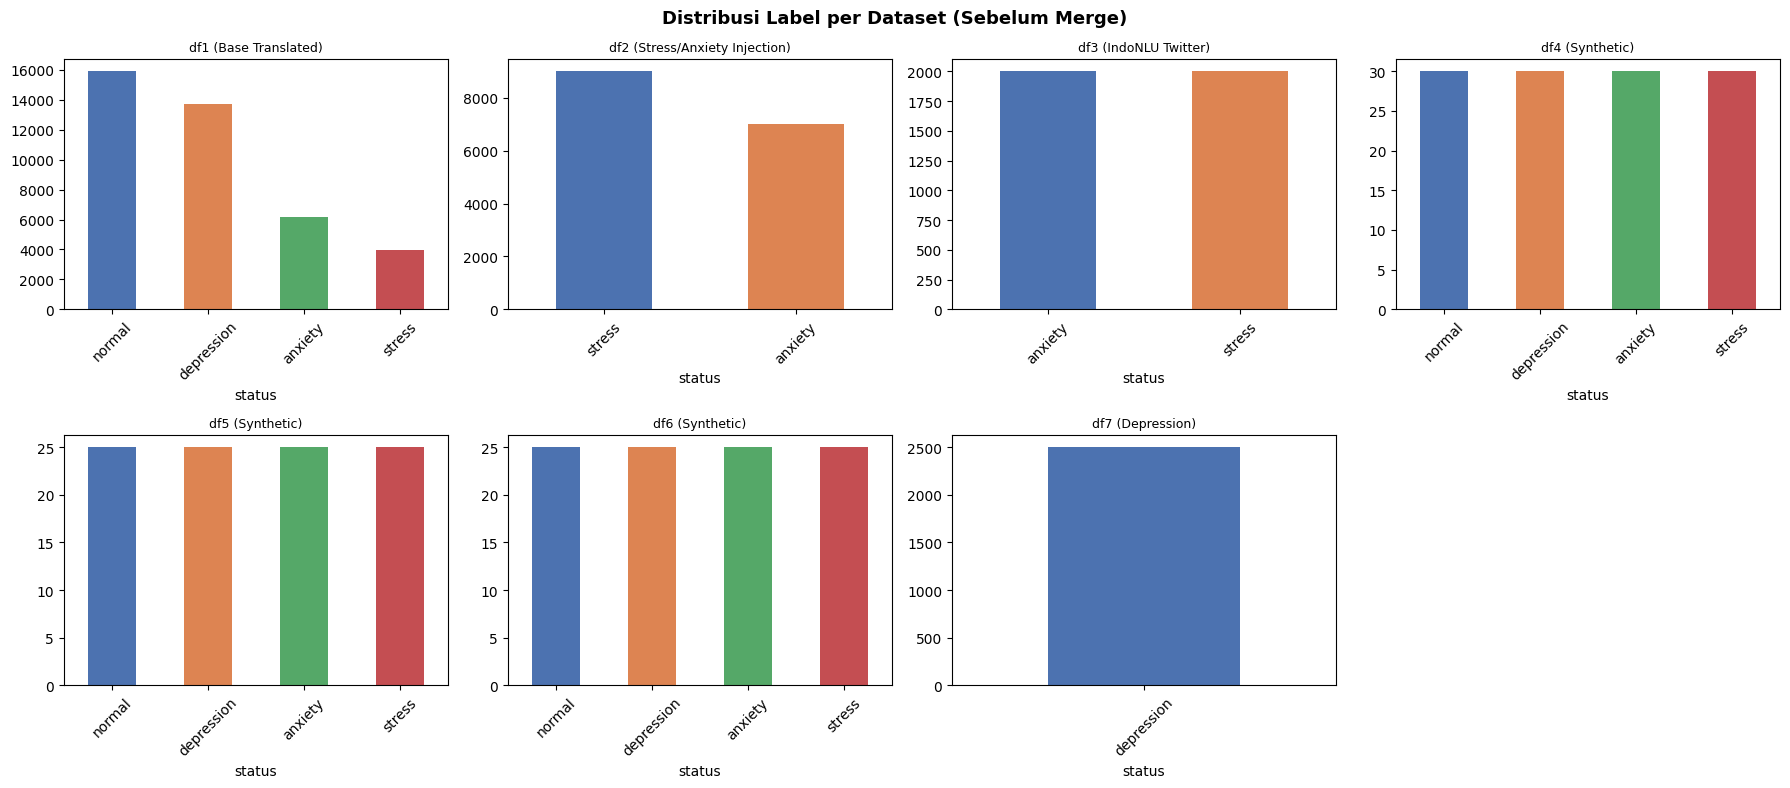

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    if 'status' in df.columns:
        df['status'].value_counts().plot(
            kind='bar', ax=axes[i], color=['#4C72B0','#DD8452','#55A868','#C44E52']
        )
        axes[i].set_title(name, fontsize=9)
        axes[i].tick_params(axis='x', rotation=45)

axes[-1].axis('off')
plt.suptitle('Distribusi Label per Dataset (Sebelum Merge)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### **df1**

In [ ]:
df1.duplicated().sum()

np.int64(0)

In [ ]:
df1['status'].value_counts()

,count
status,
normal,15910
depression,13698
anxiety,6142
stress,3996


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39746 entries, 0 to 39745
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Unnamed: 0            39746 non-null  int64 
 1   statement             39746 non-null  object
 2   status                39746 non-null  object
 3   statement_translated  39746 non-null  object
 4   statement_length      39746 non-null  int64 
 5   statement_stemming    39743 non-null  object
dtypes: int64(2), object(4)
memory usage: 1.8+ MB


In [ ]:
# Standardize column name df1 before grand merge
df1.rename(columns={'statement_translated': 'text'}, inplace=True)

# verification
print("df1 columns:", list(df1.columns))

df1 columns: ['Unnamed: 0', 'statement', 'status', 'text', 'statement_length', 'statement_stemming']


### **df2**

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   status  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [ ]:
df2.duplicated().sum()

np.int64(140)

In [ ]:
df2['status'].value_counts()

,count
status,
stress,9000
anxiety,7000


### **df3**

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    4000 non-null   object
 1   status  4000 non-null   object
dtypes: object(2)
memory usage: 62.6+ KB


In [ ]:
df3.duplicated().sum()

np.int64(34)

In [ ]:
df3['status'].value_counts()

,count
status,
anxiety,2000
stress,2000


### **df4**

In [ ]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    120 non-null    object
 1   status  120 non-null    object
dtypes: object(2)
memory usage: 2.0+ KB


In [ ]:
df4.duplicated().sum()

np.int64(0)

In [ ]:
df4['status'].value_counts()

,count
status,
normal,30
depression,30
anxiety,30
stress,30


### **df5**

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    100 non-null    object
 1   status  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df5.duplicated().sum()

np.int64(0)

In [ ]:
df5['status'].value_counts()

,count
status,
normal,25
depression,25
anxiety,25
stress,25


### **df6**

In [ ]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    100 non-null    object
 1   status  100 non-null    object
dtypes: object(2)
memory usage: 1.7+ KB


In [ ]:
df6.duplicated().sum()

np.int64(0)

In [ ]:
df6['status'].value_counts()

,count
status,
normal,25
depression,25
anxiety,25
stress,25


### **df7**

In [ ]:
df7.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    2500 non-null   object
 1   status  2500 non-null   object
dtypes: object(2)
memory usage: 39.2+ KB


In [ ]:
df7['status'].value_counts()

,count
status,
depression,2500


In [ ]:
df7.duplicated().sum()

np.int64(14)

## Pre-Processing


In [ ]:
# Combine all the data
df = pd.concat([df1, df2, df3, df4, df5, df6, df7], ignore_index=True)

# Filter only the columns you need
df = df[['text', 'status']].copy()

# GLOBAL DROP DUPLICATES
df = df.drop_duplicates(subset='text').reset_index(drop=True)

# Shuffle it so the models don’t memorize the order (SEED=42)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# final verification
print("="*50)
print("GRAND MERGE SUMMARY")
print("="*50)
print(f"Total Baris Bersih: {len(df)}")
print("\nDistribusi Kelas:")
print(df['status'].value_counts())

GRAND MERGE SUMMARY
Total Baris Bersih: 60428

Distribusi Kelas:
status
depression    15929
normal        14938
anxiety       14809
stress        14752
Name: count, dtype: int64


In [ ]:
X = df['text']
y = df['status']

# Split 1: 80% Train, 20% Temp (for val and test))
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Split 2: Divide the score into 50% for the written val and 50% for the test (10% each of the total)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print("="*50)
print("DATASET SPLIT SUMMARY")
print("="*50)
print(f"Train Set : {len(X_train)} baris")
print(f"Val Set   : {len(X_val)} baris")
print(f"Test Set  : {len(X_test)} baris")

DATASET SPLIT SUMMARY
Train Set : 48342 baris
Val Set   : 6043 baris
Test Set  : 6043 baris


In [ ]:
# TEXT CLEANING & RE-SPLIT
# This function MUST be identical to the one in the FastAPI backend
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)   # Remove URL
    text = re.sub(r'@\w+', '', text)              # Remove Mention
    text = re.sub(r'#\w+', '', text)              # Remove Hashtag
    text = re.sub(r'\d+', '', text)               # Remove Digit
    text = re.sub(r'[^\w\s]', '', text)           # Remove Special char
    text = re.sub(r'\s+', ' ', text).strip()      # Normalize Whitespace
    return text

# Apply cleaning ke dataframe induk
df['text'] = df['text'].apply(clean_text)

# Remove blank lines (if there is text that contains only links or symbols)
df = df[df['text'].str.len() > 0].reset_index(drop=True)

# RE-SPLIT (so that X_train, X_val, and X_test are clean versions)
X = df['text']
y = df['status']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Post-Cleaning Train Set : {len(X_train)} baris")

Post-Cleaning Train Set : 48342 baris


In [ ]:
# Verification of cleaning results
X_train.sample(10)

,text
11543,jika anda pernah tahu jawabannya dalam pekerja...
52342,pria temui kedai kopi
11140,berharap khawatir
56096,i dont i keep overthink everything and i am wo...
22226,alasan tinggal rumah bagus berjalan lancar aya...
39422,belajar mencintai tubuh mengundang sikap ramah...
3023,membersihkan kamarku kamar mandi sialanku butu...
50310,ketika saya diperlakukan tidak pantas oleh ses...
26276,padahal yang lain senyum ramah lohh sama fansn...
16393,malam menaruh cola lemari es lupa meminumnya


In [ ]:
# Count the word lengths in the cleaned dataframe
lengths = df['text'].apply(lambda x: len(str(x).split()))

print(f"Mean   : {lengths.mean():.0f}")
print(f"Median : {lengths.median():.0f}")
print(f"P90    : {np.percentile(lengths, 90):.0f}")
print(f"P95    : {np.percentile(lengths, 95):.0f}")
print(f"Max    : {lengths.max():.0f}")

MAX_LEN = int(np.percentile(lengths, 95))
print(f"\n[MISSION CRITICAL] MAX_LEN di-set ke: {MAX_LEN}")

Mean   : 33
Median : 24
P90    : 78
P95    : 97
Max    : 510

[MISSION CRITICAL] MAX_LEN di-set ke: 97


In [ ]:
VOCAB_SIZE = 30000

# STRICT RULE: Fit ONLY on X_train
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Transform text to integer sequence
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# Padding is placed at the end (post) so that it doesn't dominate the LSTM's initial memory
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"Shape X_train_pad : {X_train_pad.shape}")

Shape X_train_pad : (48342, 97)


In [ ]:
# Label Encoding
le = LabelEncoder()

# FIT MUST BE TRAINED
y_train_enc = to_categorical(le.fit_transform(y_train), num_classes=4)

# VAL & TEST: TRANSFORM ONLY
y_val_enc   = to_categorical(le.transform(y_val),       num_classes=4)
y_test_enc  = to_categorical(le.transform(y_test),      num_classes=4)

# Save the mapping for future reference
label_map = dict(enumerate(le.classes_))
print("Label mapping:", label_map)

Label mapping: {0: 'anxiety', 1: 'depression', 2: 'normal', 3: 'stress'}


## Modelling


In [ ]:

# ARCHITECTURE (KERAS 3)
EMBED_DIM  = 128
LSTM_UNITS = 128

# EXPLICIT INPUT LAYER (Required in Keras 3)
inputs = Input(shape=(MAX_LEN,))

# EMBEDDING LAYER
# mask_zero=True. This is REQUIRED. This prevents the LSTM from treating the zero padding as information.
x = Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBED_DIM,
    mask_zero=True
)(inputs)

# BIDIRECTIONAL LSTM
# return_sequences=True is required to ensure the output is 3D for GlobalMaxPooling
x = Bidirectional(LSTM(
    LSTM_UNITS,
    return_sequences=True,
    recurrent_dropout=0.1
))(x)

x = Dropout(0.3)(x)

# POOLING (Extracting the strongest emotional signals from the entire sequence of words)
x = GlobalMaxPooling1D()(x)

# FULLY CONNECTED LAYER (Classifier)
x = Dense(64, activation='relu')(x)
x = Dropout(0.3)(x)

# OUTPUT LAYER (4 Kelas, Mutually Exclusive -> Softmax)
outputs = Dense(4, activation='softmax')(x)

# PACKAGING AS A MODEL
model = Model(inputs=inputs, outputs=outputs)

# PRINT SUMMARY
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 97)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 97, 128)   │  3,840,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 97)        │          0 │ input_layer[0][0] │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 97, 256)   │    263,168 │ embedding[0][0],  │
│ (Bidirectional)     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 97, 256)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 256)       │          0 │ dropout[0][0]     │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │     16,448 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 4)         │        260 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,119,876 (15.72 MB)

 Trainable params: 4,119,876 (15.72 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# TRAINING PROTOCOL

# Compile Model
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',  #  Since our labels are one-hot
    metrics=['accuracy']
)

# Setup Smart Callbacks
callbacks = [
    # If val_loss doesn’t decrease over 5 epochs, stop. Don’t waste time and resources.
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    # If the model starts to plateau at a local minimum (patience=3), cut the learning rate in half.
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath='mentalku_best_model.keras',
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )
]

# Execute Training
print("Mulai training... Bakal makan waktu, pantau val_loss-nya.")
history = model.fit(
    X_train_pad, y_train_enc,
    validation_data=(X_val_pad, y_val_enc),
    epochs=50,
    batch_size=64, # Sweet spot antara training speed & gradient stability
    callbacks=callbacks
)

Mulai training... Bakal makan waktu, pantau val_loss-nya.
Epoch 1/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 0s 681ms/step - accuracy: 0.7366 - loss: 0.6935
Epoch 1: val_loss improved from None to 0.40250, saving model to mentalku_best_model.keras

Epoch 1: finished saving model to mentalku_best_model.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 540s 700ms/step - accuracy: 0.8126 - loss: 0.5174 - val_accuracy: 0.8610 - val_loss: 0.4025 - learning_rate: 0.0010
Epoch 2/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 0s 683ms/step - accuracy: 0.8914 - loss: 0.3109
Epoch 2: val_loss improved from 0.40250 to 0.38324, saving model to mentalku_best_model.keras

Epoch 2: finished saving model to mentalku_best_model.keras
756/756 ━━━━━━━━━━━━━━━━━━━━ 530s 700ms/step - accuracy: 0.8970 - loss: 0.2969 - val_accuracy: 0.8615 - val_loss: 0.3832 - learning_rate: 0.0010
Epoch 3/50
756/756 ━━━━━━━━━━━━━━━━━━━━ 0s 686ms/step - accuracy: 0.9247 - loss: 0.2231
Epoch 3: val_loss did not improve from 0.38324
756/756 ━━━━━━━━━━━━━━━━━━━━ 532s 

In [ ]:
print("Melakukan inferensi pada Test Set...")
# Probability predictions from the test set
y_pred_prob = model.predict(X_test_pad)

# Take the index with the highest probability (converted from one-hot encoding)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_enc, axis=1)

# full report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(
    y_true, y_pred,
    target_names=le.classes_
))

# Confusion Matrix
print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print(confusion_matrix(y_true, y_pred))

Melakukan inferensi pada Test Set...
189/189 ━━━━━━━━━━━━━━━━━━━━ 29s 146ms/step

CLASSIFICATION REPORT
              precision    recall  f1-score   support

     anxiety       0.85      0.85      0.85      1481
  depression       0.90      0.82      0.86      1593
      normal       0.87      0.93      0.90      1494
      stress       0.81      0.84      0.82      1475

    accuracy                           0.86      6043
   macro avg       0.86      0.86      0.86      6043
weighted avg       0.86      0.86      0.86      6043


CONFUSION MATRIX
[[1253   41   46  141]
 [  70 1311  114   98]
 [  16   35 1393   50]
 [ 131   63   49 1232]]


In [ ]:
# save the model in .keras
model.save('mentalku_best_model.keras')

# save Tokenizer (Mapping Teks -> Integer)
with open('tokenizer_lstm.pkl', 'wb') as f:
    pickle.dump(tokenizer, f)

# save Label Encoder (Mapping Integer -> Label)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# save Config
with open('config.pkl', 'wb') as f:
    pickle.dump({'MAX_LEN': MAX_LEN, 'VOCAB_SIZE': VOCAB_SIZE}, f)

print("✅ MISSION ACCOMPLISHED. Semua artefak siap di-deploy:")
print("   - mentalku_best_model.keras")
print("   - tokenizer_lstm.pkl")
print("   - label_encoder.pkl")
print("   - config.pkl")

✅ MISSION ACCOMPLISHED. Semua artefak siap di-deploy:
   - mentalku_best_model.keras
   - tokenizer_lstm.pkl
   - label_encoder.pkl
   - config.pkl
